In [1]:
import functools
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from tqdm.notebook import trange, tqdm
from torchvision.datasets import FashionMNIST
from torch.optim import Adam
from torch.utils.data import DataLoader

In [3]:
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
device

device(type='cuda')

References:

- [[Song21]](https://openreview.net/pdf?id=PxTIG12RRHS) Score-Based Generative Modeling Through Stochastic Differential Equations
- Yang Song's blog

## Variance Preserving SDE (VP)

Variance Preserving diffusion SDE (Eq 11 in [Song21]):

\begin{align*}
d \mathbf{x} = - \frac{1}{2} \beta(t) \mathbf{x} dt + \sqrt{\beta(t)}d\mathbf{w}
\end{align*}

This follows the general SDE form $d \mathbf{x} = f(\mathbf{x}, t) dt + g(t) d \mathbf{w}$. We call $f(\mathbf{x}, t)$ the **drift coefficient** and $g(t)$ the **diffusion coefficient**.

The corresponding general conditional linear Gaussian distribution is:
\begin{align*}
p(x_t|x_0) = \mathcal{N}(x_t; \alpha(t)x_0, \sigma^2(t)I)
\end{align*}
where $\alpha: [0,1] \rightarrow \mathbb{R}$,  $\sigma: [0,1] \rightarrow \mathbb{R}$

$\mu(t), \sigma(t)$ can be derived analytically from $f(\mathbf{x}, t), g(t)$.

\begin{align*}
\begin{cases}
  \mu(t) = \alpha(t)x_0 = \exp{(c(t))}x_0 \\
  \sigma^2(t) = 1 - \exp(2c(t))
\end{cases}
\end{align*}

### Implementing the VP SDE

Refer to Equations (32) and (33) in [Song21] to identify:
* $\beta(t)$
* $c(t)$
* $\mu(t)$
* $\sigma(t)$

Copy your code from `vp.py`

In [4]:
import torch
import math

class VP():
    def __init__(self, beta_min, beta_max, num_steps):
        self.beta_0 = beta_min
        self.beta_1 = beta_max
        self.num_steps = num_steps
        self.discrete_betas = torch.linspace(beta_min / num_steps, beta_max / num_steps, num_steps)
        self.alphas = 1. - self.discrete_betas

    def _beta_t(self, t):
        '''
        Caculate beta_t for a array of t.
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - beta_t (torch.Tensor): array of beta_t, shape (N,)
        '''
        # β(t) = β_0 + (β_1 - β_0) * t   [Eq. 32 of Song21]
        return self.beta_0 + (self.beta_1 - self.beta_0) * t

    def _c_t(self, t):
        '''
        Calculat c_t for a array of t.
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - c_t (torch.Tensor): array of c_t, shape (N,)
        '''
        # c(t) = -1/2 * ∫_0^t β(s)ds = -1/2 * (β_0*t + 1/2*(β_1-β_0)*t²)  [Eq. 33]
        return -0.5 * (self.beta_0 * t + 0.5 * (self.beta_1 - self.beta_0) * t ** 2)

    def marginal_prob(self, x, t):
        '''
        Compute the mean and standard deviation of the conditional distribution p(x_t|x_0).
        Args:
            - x (torch.Tensor | scalar): input, shape (N, C, H, W) or 0 for init queries
            - t (torch.Tensor | float): time, shape (N,) or scalar
        Returns:
            - mu_t:  mean,  shape (N, C, H, W)  [or scalar when x=0]
            - std_t: std,   shape (N,)           [or scalar when t is scalar]
        '''
        c_t = self._c_t(t)
        if isinstance(c_t, torch.Tensor):
            alpha_t = torch.exp(c_t)
            std_t = torch.sqrt(1. - torch.exp(2. * c_t))
        else:
            alpha_t = math.exp(c_t)
            std_t = math.sqrt(max(0., 1. - math.exp(2. * c_t)))

        if isinstance(x, torch.Tensor) and x.dim() >= 2:
            view_shape = (-1,) + (1,) * (x.dim() - 1)
            mu_t = alpha_t.view(*view_shape) * x
        else:
            mu_t = alpha_t * x
        return mu_t, std_t

    # alias used throughout the notebook
    marginal_proba = marginal_prob

    def drift(self, x, t):
        '''
        Compute the VP drift coefficient f(x, t) = -½ β(t) x
        Args:
            - x (torch.Tensor): input tensor, shape (N, C, H, W)
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - drift (torch.Tensor): drift term, shape (N, C, H, W)
        '''
        beta_t = self._beta_t(t)
        if isinstance(beta_t, torch.Tensor):
            view_shape = (-1,) + (1,) * (x.dim() - 1)
            return -0.5 * beta_t.view(*view_shape) * x
        return -0.5 * beta_t * x

    def diffusion(self, t):
        '''
        Compute the VP diffusion coefficient g(t) = √β(t)
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - diffusion (torch.Tensor): diffusion term, shape (N,)
        '''
        beta_t = self._beta_t(t)
        if isinstance(beta_t, torch.Tensor):
            return torch.sqrt(beta_t)
        return math.sqrt(beta_t)

## Sampling with VP sde

As per Appendix E of [Song21], recall that for any SDE of the form
\begin{align*}
d \mathbf{x} = \mathbf{f}(\mathbf{x}, t) dt + g(t) d\mathbf{w},
\end{align*}
the reverse-time SDE is given by
\begin{align*}
d \mathbf{x} = [\mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d \bar{\mathbf{w}}.
\end{align*}

We use the [Euler-Maruyama](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method) numerical method to solve for the reverse-time SDE. This method relies on discretizing the SDE, replacing $dt$ with $\Delta t$ and $d \mathbf{w}$ with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, g^2(t) \Delta t \mathbf{I})$.

This lead to the following iteration rule:
\begin{align}
\mathbf{x}_{t-\Delta t} =
\mathbf{x}_t
- \mathbf{f}(\mathbf{x}_t, t)\Delta t
+ g^2(t) s_\theta(\mathbf{x}_t, t)\Delta t
+ g(t)\sqrt{\Delta_t}\mathbf{z}_t.
\end{align}

Note: for the last step (i.e. $t-\Delta_t = 0$), we do not wish to add back noise ($g(t)\sqrt{\Delta_t}\mathbf{z}_t$).

In [5]:
def Euler_Maruyama_sampler(score_model,
                           sde,
                           batch_size,
                           num_steps=1000,
                           device='cuda',
                           eps=1e-3):
    '''
    Euler-Maruyama sampler for SDEs.
    Args:
        - score_model (nn.Module): score-based model
        - sde (SDE): SDE, VP class
        - batch_size (int): batch size
        - num_steps (int): number of time steps
        - device (str): device
        - eps (float): truncation time to avoid numerical instability
    Returns:
        - x_next (torch.Tensor): samples from the SDE, shape (batch_size, 1, 28, 28)
    '''
    # Initialise x(t=1) ~ N(0, σ(1)² I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]

    # Time grid from 1 down to eps with num_steps uniform points
    time_steps = torch.linspace(1., eps, num_steps, device=device)

    step_size = time_steps[0] - time_steps[1]

    x_next = init_x
    with torch.no_grad():
        for time_step in tqdm(time_steps):
            batch_time = torch.ones(batch_size, device=device) * time_step

            score = score_model(x_next, batch_time)          # s_θ(x_t, t)
            g_t   = sde.diffusion(batch_time)                # √β(t),  shape (B,)
            f_xt  = sde.drift(x_next, batch_time)            # -½β(t)x, shape (B,1,28,28)

            # Reverse-SDE mean: x - f(x,t)Δt + g²(t)·s_θ·Δt
            mean_x = x_next - f_xt * step_size + g_t[:, None, None, None] ** 2 * score * step_size

            # Add diffusion noise everywhere except the very last step
            if time_step > eps:
                x_next = mean_x + g_t[:, None, None, None] * torch.sqrt(step_size) * torch.randn_like(x_next)
            else:
                x_next = mean_x
    return x_next

In [6]:
def predictor_corrector_sampler(score_model,
                                sde,
                                batch_size,
                                num_steps=1000,
                                device='cuda',
                                snr=0.16,
                                num_corrector_steps=1,
                                eps=1e-3):
    '''
    Predictor-corrector sampler for SDEs.
    Args:
        - score_model (nn.Module): score-based model
        - sde (SDE): SDE, VP class
        - batch_size (int): batch size
        - num_steps (int): number of time steps
        - device (str): device
        - snr (float): signal-to-noise ratio
        - num_corrector_steps (int): number of corrector steps
        - eps (float): truncation time to avoid numerical instability
    '''
    # Initialise x(t=1) ~ N(0, σ(1)² I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]

    # Time grid from 1 down to eps
    time_steps = torch.linspace(1., eps, num_steps, device=device)

    step_size = time_steps[0] - time_steps[1]

    x_next = init_x
    with torch.no_grad():
        for time_step in tqdm(time_steps):
            batch_time_steps = torch.ones(batch_size, device=device) * time_step
            int_time_step = int(time_step * (sde.num_steps - 1))
            alpha_t = sde.alphas[int_time_step]

            # ── Corrector: annealed Langevin dynamics (Algorithm 5 of Song21) ──
            for j in range(num_corrector_steps):
                score = score_model(x_next, batch_time_steps)
                noise = torch.randn_like(x_next)

                # Per-sample SNR-based step size: ε = 2α * (snr * ||z||/||s||)²
                score_norm = torch.norm(score.reshape(batch_size, -1), dim=-1)
                noise_norm = torch.norm(noise.reshape(batch_size, -1), dim=-1)
                langevin_step = 2 * alpha_t * (snr * noise_norm / score_norm.clamp(min=1e-8)) ** 2

                x_next = (x_next
                          + langevin_step[:, None, None, None] * score
                          + torch.sqrt(2 * langevin_step[:, None, None, None]) * noise)

            # ── Predictor: one Euler-Maruyama reverse step ───────────────────
            score = score_model(x_next, batch_time_steps)
            g_t  = sde.diffusion(batch_time_steps)          # shape (B,)
            f_xt = sde.drift(x_next, batch_time_steps)      # shape (B,1,28,28)

            mean_x = x_next - f_xt * step_size + g_t[:, None, None, None] ** 2 * score * step_size

            if time_step > eps:
                x_next = mean_x + g_t[:, None, None, None] * torch.sqrt(step_size) * torch.randn_like(x_next)
            else:
                x_next = mean_x
    return x_next

## Setup -- no TODOs to fill in here :)

### Config

In [7]:
n_epochs = 50
batch_size = 64
lr = 1e-4
num_steps=1000
checkpoint_dir = './checkpoints/'

### Dataset

In [8]:
# training dataset
train_transforms = transforms.Compose([transforms.ToTensor()])
train_dataset = FashionMNIST('.', train=True, transform=train_transforms, download=True);
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.2MB/s]


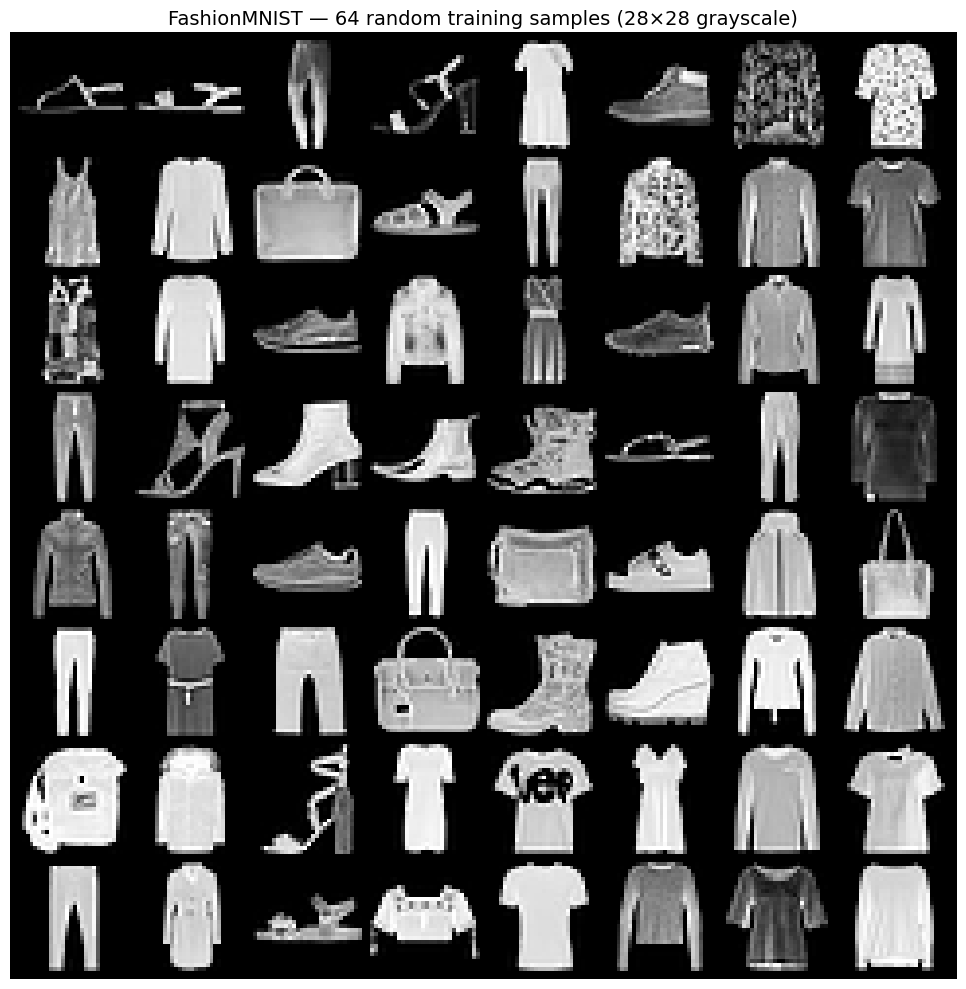

Image shape: torch.Size([64, 1, 28, 28])
Classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


In [20]:
# Problem 5.C.i: Dataset Visualization — 64 FashionMNIST samples
from torchvision.utils import make_grid

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

images, labels = next(iter(DataLoader(train_dataset, batch_size=64, shuffle=True)))

grid = make_grid(images, nrow=8, padding=2, normalize=True)

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('FashionMNIST — 64 random training samples (28×28 grayscale)', fontsize=14)
plt.tight_layout()
plt.show()

print("Image shape:", images.shape)   # (64, 1, 28, 28)
print("Classes:", ', '.join(class_names))

### Score-matching model

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class GaussianFourierProjection(nn.Module):
    """Gaussian random features for encoding time steps."""
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        # Randomly sample weights during initialization. These weights are fixed
        # during optimization and are not trainable.
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class Dense(nn.Module):
    """A fully connected layer that reshapes outputs to feature maps."""
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.dense(x)[..., None, None]


class ScoreNet(nn.Module):
    """A time-dependent score-based model built upon U-Net architecture."""

    def __init__(self, marginal_proba, channels=[32, 64, 128, 256], embed_dim=256):
        """Initialize a time-dependent score-based network.

        Args:
          marginal_proba: A function that takes time t and gives the standard
            deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
          channels: The number of channels for feature maps of each resolution.
          embed_dim: The dimensionality of Gaussian random feature embeddings.
        """
        super().__init__()
        # Gaussian random feature embedding layer for time
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
             nn.Linear(embed_dim, embed_dim))
        # Encoding layers where the resolution decreases
        self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
        self.dense1 = Dense(embed_dim, channels[0])
        self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
        self.dense2 = Dense(embed_dim, channels[1])
        self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
        self.dense3 = Dense(embed_dim, channels[2])
        self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
        self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
        self.dense4 = Dense(embed_dim, channels[3])
        self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])

        # Decoding layers where the resolution increases
        self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False)
        self.dense5 = Dense(embed_dim, channels[2])
        self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
        self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)
        self.dense6 = Dense(embed_dim, channels[1])
        self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
        self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)
        self.dense7 = Dense(embed_dim, channels[0])
        self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
        self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)

        # The swish activation function
        self.act = lambda x: x * torch.sigmoid(x)
        self.marginal_proba = marginal_proba

    def forward(self, x, t):
        # Obtain the Gaussian random feature embedding for t
        embed = self.act(self.embed(t))
        # Encoding path
        h1 = self.conv1(x)
        ## Incorporate information from t
        h1 += self.dense1(embed)
        ## Group normalization
        h1 = self.gnorm1(h1)
        h1 = self.act(h1)
        h2 = self.conv2(h1)
        h2 += self.dense2(embed)
        h2 = self.gnorm2(h2)
        h2 = self.act(h2)
        h3 = self.conv3(h2)
        h3 += self.dense3(embed)
        h3 = self.gnorm3(h3)
        h3 = self.act(h3)
        h4 = self.conv4(h3)
        h4 += self.dense4(embed)
        h4 = self.gnorm4(h4)
        h4 = self.act(h4)

        # Decoding path
        h = self.tconv4(h4)
        ## Skip connection from the encoding path
        h += self.dense5(embed)
        h = self.tgnorm4(h)
        h = self.act(h)
        h = self.tconv3(torch.cat([h, h3], dim=1))
        h += self.dense6(embed)
        h = self.tgnorm3(h)
        h = self.act(h)
        h = self.tconv2(torch.cat([h, h2], dim=1))
        h += self.dense7(embed)
        h = self.tgnorm2(h)
        h = self.act(h)
        h = self.tconv1(torch.cat([h, h1], dim=1))

        # Normalize output
        _, std = self.marginal_proba(x, t)
        h = h / std[:, None, None, None]
        return h

### Loss function

In [10]:
def loss_fn(model, x, sde, eps=1e-5):
    """ Inputs:
          model: score model (i.e. diffusion model)
          x: batch of images
          sde: instance of VP class
          eps: parameter for numerical stability (1e-5 for learning, 1e-3 for sampling)
    """
    random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
    z = torch.randn_like(x, device=x.device)
    mean, std = sde.marginal_proba(x, random_t)
    perturbed_x = mean + z * std[:, None, None, None]

    # predict the score function for each perturbed x in the batch and its corresponding random t
    score = model(perturbed_x, random_t)

    # compute loss
    losses = score * std[:, None, None, None] + z
    loss = torch.mean(torch.sum(losses**2, dim=(1,2,3)))
    return loss

## Train the score model

In [11]:
# VP sde
def train(sde_params):
    beta_min, beta_max = sde_params
    sde = VP(beta_min, beta_max, num_steps)

    score_model = ScoreNet(marginal_proba=sde.marginal_proba)
    score_model = score_model.to(device)
    optimizer = Adam(score_model.parameters(), lr=lr)

    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    params_str = '{}_{}'.format(beta_min, beta_max)
    checkpoint_path = checkpoint_dir+'ckpt_{}_{}epochs_{}.pth'.format("fashionmnist", n_epochs, params_str)

    # load checkpoint if existing
    if os.path.exists(checkpoint_path):
        score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print("model loaded from checkpoint!")
    # otherwise train from scratch
    else:
        losses = []
        patience = 0
        tqdm_epoch = trange(n_epochs)
        for epoch in tqdm_epoch:
            avg_loss = 0.
            num_items = 0
            for x, y in train_loader:
                x = x.to(device)
                loss = loss_fn(score_model, x, sde)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                avg_loss += loss.item() * x.shape[0]
                num_items += x.shape[0]
            tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
            losses.append(avg_loss/ num_items)

            # Saving: loss need to decrease by 2pts
            if len(losses)>=2:
                if losses[-2] - losses[-1] >= 0.5:
                    torch.save(score_model.state_dict(), checkpoint_path)
                    patience = 0
                else:
                    patience +=1

            # Patience: if no significant improvement in 3 epochs, early stopping
            if patience >= 3:
                break

        plt.plot(range(len(losses)), losses)
        plt.yscale('log')
        plt.show()
    return score_model

## Generation of new samples

In [12]:
from torchvision.utils import make_grid
def plot_images(images):
    sample_grid = make_grid(images, nrow=int(np.sqrt(images.shape[0])))
    plt.figure(figsize=(6,6))
    plt.axis('off')
    plt.imshow(sample_grid.cpu().permute(1, 2, 0).squeeze())
    plt.show()

In [13]:
def setup_for_sampling(sde_params):
    beta_min, beta_max = sde_params
    params_str = '{}_{}'.format(beta_min, beta_max)
    checkpoint_path = checkpoint_dir+'ckpt_{}_{}epochs_{}.pth'.format("fashionmnist", n_epochs, params_str)

    sde = VP(beta_min, beta_max, num_steps)
    score_model = ScoreNet(marginal_proba=sde.marginal_proba)
    score_model = score_model.to(device)
    score_model.eval()
    score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    return sde, score_model

### Sampling

  0%|          | 0/50 [00:00<?, ?it/s]

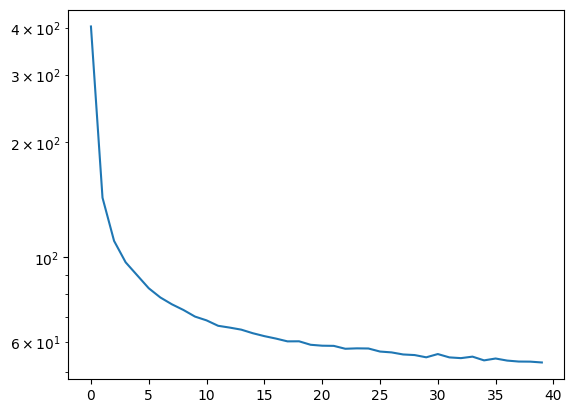

In [ ]:
sde_params = [0.01, 5.0]
score_model = train(sde_params)

In [16]:
beta_min, beta_max = sde_params
sde = VP(beta_min, beta_max, num_steps)

  0%|          | 0/1000 [00:00<?, ?it/s]

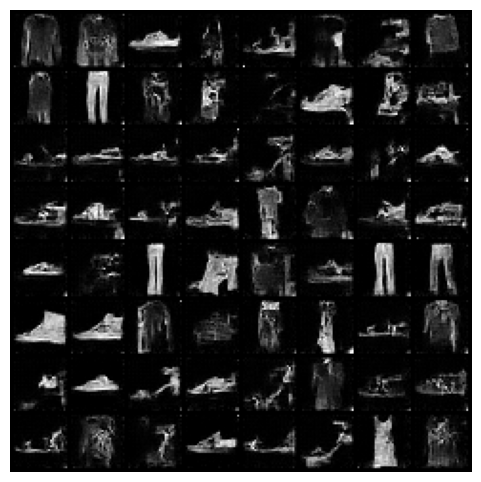

In [17]:
samples = Euler_Maruyama_sampler(score_model, sde, batch_size, num_steps=1000)
plot_images(samples)

  0%|          | 0/1000 [00:00<?, ?it/s]

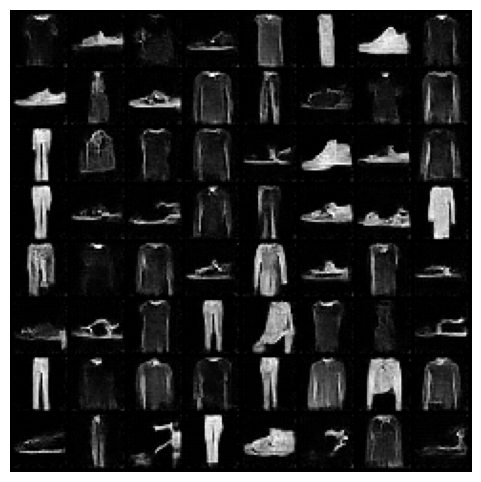

In [18]:
samples = predictor_corrector_sampler(score_model, sde, batch_size, num_steps=1000)
plot_images(samples)

  0%|          | 0/1000 [00:00<?, ?it/s]

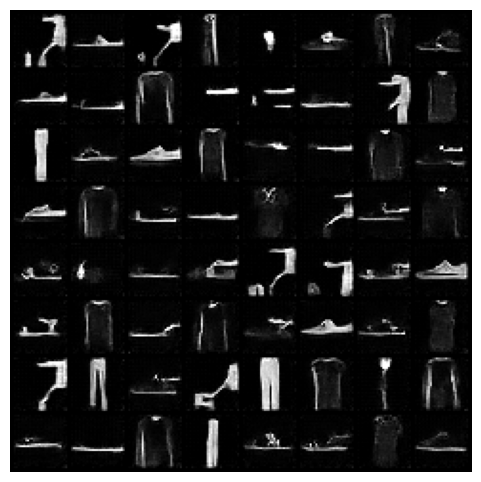

In [19]:
samples = predictor_corrector_sampler(score_model, sde, batch_size, num_corrector_steps=5, num_steps=1000)
plot_images(samples)

# Part 4D: Diffusion models for inverse problems

## EC (10pts) : inpainting -- keep until you're done with the pset
This part will require you to read and understand [[Song22]](https://arxiv.org/pdf/2111.08005.pdf) Solving Inverse Problems In Medical Imaging With Score-Based Generative Models.

In our toy example, our measurement matrix A will be an explicit inpainting matrix that replaces some of the pixels in an image by 0 (blackening them out).

Your job will be to modify the sampling process to include conditioning on the perturbed measurements at various t.

**Important: do not attempt until you are entirely satisfied with your work for all of the rest of the assignment (Parts 1 through 5).**

**Important: Minimum guidance will be provided in OH or on Piazza. 🎶🎵You're on your own, kid. You always have been🎵🎶**

**Expectations:** The expected result is a plot with 3 rows: clean images, inpainted images, reconstructed images. The plot **must** include the PSNR of each reconstructed image. You should use at least 5 clean images. We wrote the plotting function for you. We also expect you to explain and justify your implementation choices. Everything (plot, explanations, justifications) **must** appear in your submission PDF.

In [21]:
# helper function to inpaint with 0 pixels and get the subsampling matrix
def inpaint(images, ratio=0.05):
    num_pixels = images.shape[-2] * images.shape[-1]
    num_samples = int(ratio * num_pixels)
    # create subsampling matrix A
    A = torch.eye(num_pixels, device=images.device)
    for pixel in random.sample(range(0, num_pixels), num_samples):
        A[pixel][pixel] = 0
    # black out pixels in images using A (a binary matrix with zeroes where we want to black out pixels)
    inpainted_images = images.clone()
    for i in range(len(images)):
        inpainted_images[i] = torch.reshape(torch.matmul(A, inpainted_images[i].view(num_pixels)), images[0].shape)
    return inpainted_images, A

In [22]:
# helper function to compute the peak signal-to-noise ratio (PSNR)
def psnr(clean, noisy):
    # our range of values is [0.,1.]
    eps = 1e-8
    mse = torch.mean((clean - noisy) ** 2)
    psnr = 10 * torch.log10(1.0 / (mse + eps))
    return psnr

In [23]:
# helper function to plot samples
def plot_before_after(clean_images, imgs_before, imgs_after, title=""):
    assert(imgs_before.shape[0] == imgs_after.shape[0])
    fig, axs = plt.subplots(3, imgs_before.shape[0], figsize=(16, 10))
    # plot 3 rows: clean, then subsampled, then denoised
    for i, images in enumerate([clean_images, imgs_before, imgs_after]):
        for j, image in enumerate(images):
            axs[i][j].imshow(image.cpu().permute(1, 2, 0).squeeze())
            axs[i][j].set_xticks([])
            axs[i][j].set_yticks([])
    # compute PSNR
    for j, image in enumerate(imgs_after):
        clean = clean_images[j].cpu().permute(1,2,0).squeeze()
        noisy = image.cpu().permute(1,2,0).squeeze()
        psnr_val = psnr(clean, noisy).item()
        axs[2][j].set_title('PSNR: {:.3f}'.format(psnr_val), y=-0.2)
    fig.suptitle(title, size=20)

In [28]:
# helper functions to condition the reverse diffusion
def get_y_t(images, t, marginal_proba):
    # vector of t
    ts = t * torch.ones(images.shape[0], device=images.device)
    ts = ts[:, None, None, None]

    # sample some noise
    z = torch.randn_like(images)

    # perturb at level t
    _, std = marginal_proba(x=0, t=t)
    perturbed_images = images + z * std
    return perturbed_images

def lbda_scheduler(t, lbda, param):
    param = torch.tensor(param)
    f_t = param*t
    lbda = lbda * f_t
    return lbda

def condition_on_inpainted_y(raw_images, x_t, t, marginal_prob_std, A, lbda=.01, lbda_param=10):
    y_t = get_y_t(raw_images, t, marginal_prob_std)
    lbda = lbda_scheduler(t, lbda, param=lbda_param)
    # P_inv: pseudo-inverse of the measurement noise covariance — identity for zero-noise inpainting.
    # T:     identity transition (the current x_t is used directly for unknown pixels).
    num_pixels = A.shape[0]
    dev = x_t.device
    P_inv = torch.eye(num_pixels, device=dev)
    T     = torch.eye(num_pixels, device=dev)
    A     = A.to(dev)
    # Expand scalar lbda to batch vector so lbda[:, None] gives shape (B, 1),
    # and move to the correct device (lbda_scheduler creates tensors on CPU).
    if lbda.dim() == 0:
        lbda = lbda.unsqueeze(0).expand(x_t.shape[0])
    lbda = lbda.to(dev)
    # turn images into column vectors
    flat_y_t = torch.flatten(y_t, start_dim=1)
    flat_x_t = torch.flatten(x_t, start_dim=1)
    lbda = lbda[:, None]
    # x_prime is a weighted function of x and y
    y_influence = lbda * torch.matmul(A, torch.matmul(P_inv, flat_y_t.T)).T
    x_influence = (1 - lbda) * torch.matmul(A, torch.matmul(T, flat_x_t.T)).T + \
                  torch.matmul(torch.eye(A.shape[0], device=A.device) - A,
                               torch.matmul(T, flat_x_t.T)).T
    x_t_prime = torch.reshape(y_influence + x_influence, x_t.shape)
    return x_t_prime


def conditional_reverse_diffusion(score_model, sde, clean_images, A,
                                  num_steps=1000, device='cuda', eps=1e-3):
    """Reverse diffusion conditioned on inpainting observations (Song22)."""
    batch_size = clean_images.shape[0]

    # Initialise x(t=1) ~ N(0, σ(1)² I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]

    time_steps = torch.linspace(1., eps, num_steps, device=device)
    step_size  = time_steps[0] - time_steps[1]

    with torch.no_grad():
        for time_step in tqdm(time_steps):
            t_val      = time_step.item()           # scalar float for marginal_prob / lbda_scheduler
            batch_time = torch.ones(batch_size, device=device) * time_step

            # EM reverse step
            score = score_model(x, batch_time)
            g_t   = sde.diffusion(batch_time)                   # (B,)
            f_xt  = sde.drift(x, batch_time)                    # (B,1,28,28)
            mean_x = x - f_xt * step_size + g_t[:, None, None, None] ** 2 * score * step_size
            if time_step > eps:
                x = mean_x + g_t[:, None, None, None] * torch.sqrt(step_size) * torch.randn_like(x)
            else:
                x = mean_x

            # Condition on known pixels at every step
            x = condition_on_inpainted_y(clean_images, x, t_val, sde.marginal_prob, A)

    return x

  0%|          | 0/1000 [00:00<?, ?it/s]

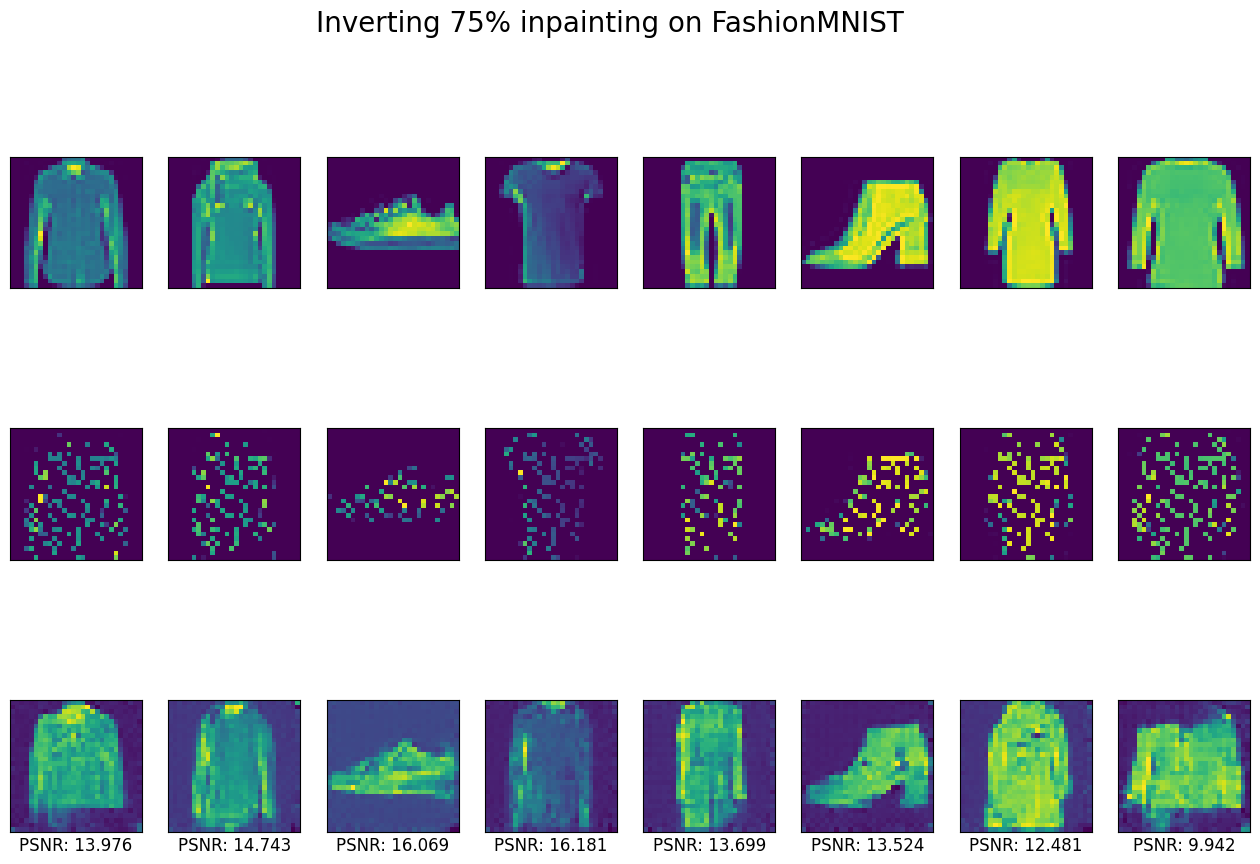

In [29]:
# Inpainted images
num_images = 8
data, _ = next(iter(train_loader))
clean_images = data[:num_images].to(device)
corrupted_images, A = inpaint(clean_images, ratio=0.75)

# Recover via conditioned reverse diffusion
recovered_images = conditional_reverse_diffusion(score_model, sde, clean_images, A, device=device)

# Expected plot
plot_before_after(clean_images, corrupted_images, recovered_images, title="Inverting 75% inpainting on FashionMNIST")

# Part 6: Rectified Flow

## Problem 6.A: Forward Process, Training Loss, and Combined Loss Curves

The forward process and loss are implemented in `diffusion/rectflow.py` and trained via
`scripts/train_rectflow.py`.  Run training with:

```
python scripts/train_rectflow.py --epochs 50 --save_dir runs/rectflow
```

The cell below loads the saved loss arrays and plots both VP and Rectified Flow curves together.

In [31]:
import os, glob

# Locate the hw4 repo root (wherever train_rectflow.py lives)
hits = glob.glob("/content/**/scripts/train_rectflow.py", recursive=True)
if hits:
    hw4_root = os.path.dirname(os.path.dirname(hits[0]))
    %cd {hw4_root}
else:
    print("⚠️  Could not find train_rectflow.py — make sure the hw4 repo is cloned under /content")

os.makedirs("runs/rectflow", exist_ok=True)

!python scripts/train_rectflow.py \
    --epochs 50 \
    --lr 1e-4 \
    --batch_size 128 \
    --save_dir runs/rectflow \
    --device cuda

⚠️  Could not find train_rectflow.py — make sure the hw4 repo is cloned under /content
python3: can't open file '/content/scripts/train_rectflow.py': [Errno 2] No such file or directory


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load loss curves (adjust paths if your save_dir differs) ──────────────────
vp_losses   = np.load("runs/vp/train_losses.npy")        # VP  losses saved by train_vp.py
rf_losses   = np.load("runs/rectflow/train_losses.npy")  # RF  losses saved by train_rectflow.py

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(range(1, len(vp_losses) + 1), vp_losses, label="VP-SDE (DDPM)", color="steelblue")
ax.semilogy(range(1, len(rf_losses) + 1), rf_losses, label="Rectified Flow", color="darkorange")

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (log scale)")
ax.set_title("VP-SDE vs. Rectified Flow — Training Loss on FashionMNIST")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("figures/combined_loss_curves.png", dpi=150)
plt.show()

print(f"Final VP  loss : {vp_losses[-1]:.4f}")
print(f"Final RF  loss : {rf_losses[-1]:.4f}")

# Part 5: Diffusion models on a larger scale

As mentioned in the write-up, you only need to include your code for plotting in this notebook for part 5. Here we provide some helper code if you run the experiments here in Google Colab.

### Helper code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install blobfile mpi4py

#### Change the directory (TODO)

In [ ]:
directory = '/content/drive/MyDrive/path/to/guided-diffusion/repo'

In [ ]:
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_classifier.pt -P {directory}/models
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion_uncond.pt -P {directory}/models
%cd {directory}

In [ ]:
!mv scripts/classifier_sample.py classifier_sample.py

#### Example code for running a script

In [ ]:
import os
# specify directory to save samples
os.environ['OPENAI_LOGDIR'] = '/content/test'

In [ ]:
# define flags
SAMPLE_FLAGS = """
    --batch_size 1
    --num_samples 2
    --timestep_respacing 250
"""
MODEL_FLAGS = """
    --attention_resolutions 32,16,8
    --class_cond False
    --diffusion_steps 1000
    --image_size 256
    --learn_sigma True
    --noise_schedule linear
    --num_channels 256
    --num_head_channels 64
    --num_res_blocks 2
    --resblock_updown True
    --use_fp16 True
    --use_scale_shift_norm True
"""

# run a script
!python classifier_sample.py {MODEL_FLAGS.replace('\n', '')} \
    --classifier_scale 10.0 \
    --classifier_path models/256x256_classifier.pt \
    --model_path models/256x256_diffusion_uncond.pt \
    {SAMPLE_FLAGS.replace('\n', '')}

### A: unconditional generation

In [ ]:
# todo

### B: progression over time visualization

In [ ]:
# todo

### C: interpolation visualization

In [ ]:
# todo

### D: conditional generation

In [ ]:
# todo

### E: conditional generation with different classifier scales

In [ ]:
# todo